In [1]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

/Users/yo/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# LOAD DATA

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train shape:", train.shape)
print("Test shape :", test.shape)

display(train.head())

Train shape: (360954, 20)
Test shape : (51063, 19)


,id,observation_timestamp,station,year,month,day,hour,current_PM2_5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,PM2_5_next_hour
0,AQ_249AF8D9D878,2013-03-01 00:00:00,Aotizhongxin,2013,3,1,0,4.00,4.00,4.00,7.00,300.00,77.00,-0.70,"1,023.00",-18.80,0.00,NNW,4.40,8.00
1,AQ_EB620EFFEEC8,2013-03-01 00:00:00,Changping,2013,3,1,0,3.00,6.00,13.00,7.00,300.00,85.00,-2.30,"1,020.80",-19.70,0.00,E,0.50,3.00
2,AQ_27EEFC23DFA3,2013-03-01 00:00:00,Dingling,2013,3,1,0,4.00,4.00,3.00,NaN,200.00,82.00,-2.30,"1,020.80",-19.70,0.00,E,0.50,7.00
3,AQ_C2DEB5BEFD7E,2013-03-01 00:00:00,Dongsi,2013,3,1,0,9.00,9.00,3.00,17.00,300.00,89.00,-0.50,"1,024.50",-21.40,0.00,NNW,5.70,4.00
4,AQ_8B32BEDFDF0D,2013-03-01 00:00:00,Guanyuan,2013,3,1,0,4.00,4.00,14.00,20.00,300.00,69.00,-0.70,"1,023.00",-18.80,0.00,NNW,4.40,4.00


In [3]:
# BASIC DATA INSPECTION

print("TRAIN INFO")
print("=" * 60)
train.info()

print("\nTEST INFO")
print("=" * 60)
test.info()

TRAIN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360954 entries, 0 to 360953
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     360954 non-null  object 
 1   observation_timestamp  360954 non-null  object 
 2   station                360954 non-null  object 
 3   year                   360954 non-null  int64  
 4   month                  360954 non-null  int64  
 5   day                    360954 non-null  int64  
 6   hour                   360954 non-null  int64  
 7   current_PM2_5          358488 non-null  float64
 8   PM10                   359032 non-null  float64
 9   SO2                    356291 non-null  float64
 10  NO2                    353433 non-null  float64
 11  CO                     345122 non-null  float64
 12  O3                     352455 non-null  float64
 13  TEMP                   360777 non-null  float64
 14  PRES                   36

In [4]:
# Column comparison

print("Train columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

print("\nColumns only in train:")
print(set(train.columns) - set(test.columns))

Train columns:
['id', 'observation_timestamp', 'station', 'year', 'month', 'day', 'hour', 'current_PM2_5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'PM2_5_next_hour']

Test columns:
['id', 'observation_timestamp', 'station', 'year', 'month', 'day', 'hour', 'current_PM2_5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM']

Columns only in train:
{'PM2_5_next_hour'}


In [5]:
# TIMESTAMP PROCESSING

train["observation_timestamp"] = pd.to_datetime(
    train["observation_timestamp"]
)

test["observation_timestamp"] = pd.to_datetime(
    test["observation_timestamp"]
)

print("Train period:")
print(train["observation_timestamp"].min(),
      "to",
      train["observation_timestamp"].max())

print("\nTest period:")
print(test["observation_timestamp"].min(),
      "to",
      test["observation_timestamp"].max())

Train period:
2013-03-01 00:00:00 to 2016-08-31 22:00:00

Test period:
2016-08-31 23:00:00 to 2017-02-28 22:00:00


In [3]:
print("\nStations:")
print(train["station"].value_counts())


Stations:
station
Wanliu           30393
Guanyuan         30199
Nongzhanguan     30175
Gucheng          30166
Dingling         30141
Tiantan          30102
Wanshouxigong    30091
Dongsi           30079
Changping        29992
Shunyi           29940
Aotizhongxin     29846
Huairou          29830
Name: count, dtype: int64


In [6]:
# NUMERICAL SUMMARY

numerical_cols = [
    "current_PM2_5",
    "PM10",
    "SO2",
    "NO2",
    "CO",
    "O3",
    "TEMP",
    "PRES",
    "DEWP",
    "RAIN",
    "WSPM",
    "PM2_5_next_hour"
]

display(
    train[numerical_cols]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5,
                           0.75, 0.95, 0.99])
    .T
)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
current_PM2_5,"358,488.00",77.99,77.62,2.00,3.00,6.00,21.00,55.00,108.00,235.00,353.00,999.00
PM10,"359,032.00",103.52,88.92,2.00,5.00,10.00,37.00,82.00,144.00,273.00,404.00,999.00
SO2,"356,291.00",16.38,22.40,0.29,1.43,2.00,3.00,7.71,20.00,63.00,107.00,500.00
NO2,"353,433.00",49.49,34.37,1.03,2.00,8.00,23.00,42.00,69.00,115.00,154.00,290.00
CO,"345,122.00","1,184.51","1,085.44",100.00,100.00,200.00,500.00,900.00,"1,500.00","3,300.00","5,500.00","10,000.00"
O3,"352,455.00",60.84,58.11,0.21,1.00,2.00,13.00,49.00,86.00,184.00,249.00,"1,071.00"
TEMP,"360,777.00",14.47,11.38,-19.90,-8.00,-4.00,4.40,16.10,23.90,31.00,34.00,41.60
PRES,"360,776.00","1,009.76",10.35,982.40,990.20,994.30,"1,001.40","1,009.00","1,017.80","1,027.10","1,032.00","1,042.80"
DEWP,"360,772.00",3.28,13.83,-43.40,-24.90,-19.70,-8.10,4.50,15.80,22.30,24.70,29.10
RAIN,"360,780.00",0.07,0.83,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.40,72.50


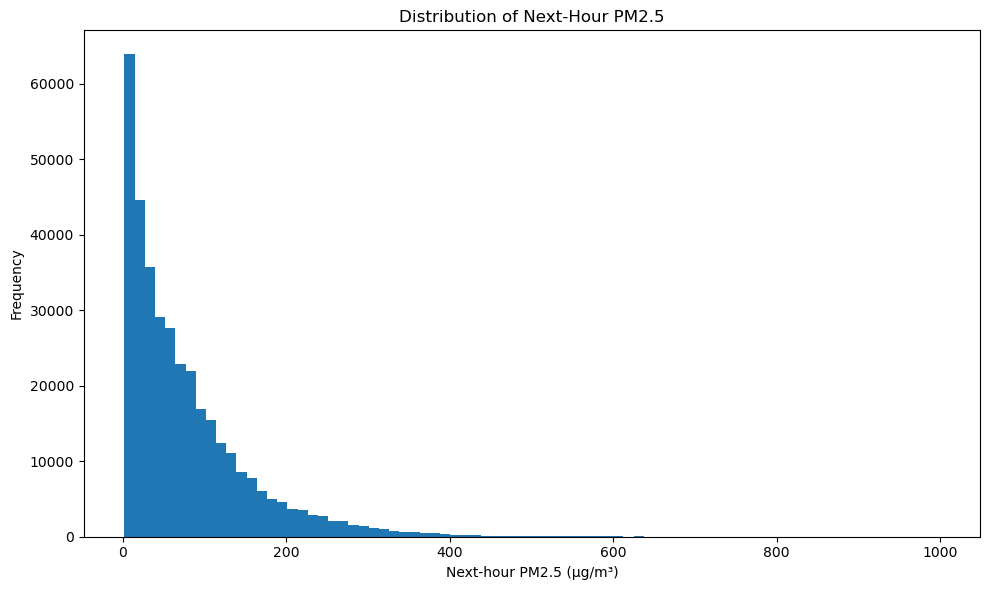

In [7]:
# TARGET DISTRIBUTION

target = "PM2_5_next_hour"

plt.figure(figsize=(10, 6))

plt.hist(
    train[target],
    bins=80
)

plt.xlabel("Next-hour PM2.5 (μg/m³)")
plt.ylabel("Frequency")
plt.title("Distribution of Next-Hour PM2.5")

plt.tight_layout()
plt.show()

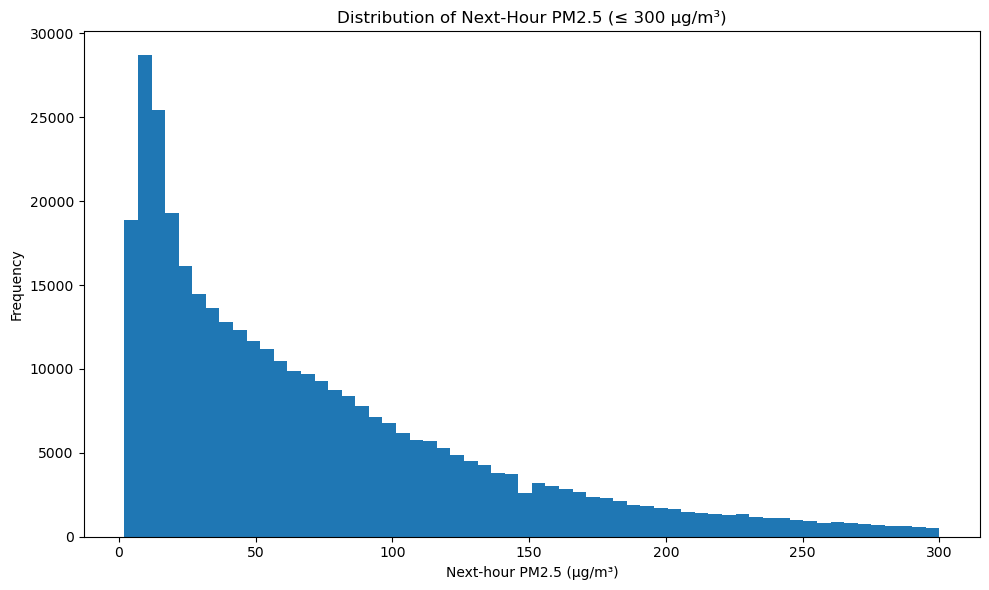

In [8]:
plt.figure(figsize=(10, 6))

plt.hist(
    train.loc[train[target] <= 300, target],
    bins=60
)

plt.xlabel("Next-hour PM2.5 (μg/m³)")
plt.ylabel("Frequency")
plt.title("Distribution of Next-Hour PM2.5 (≤ 300 μg/m³)")

plt.tight_layout()
plt.show()

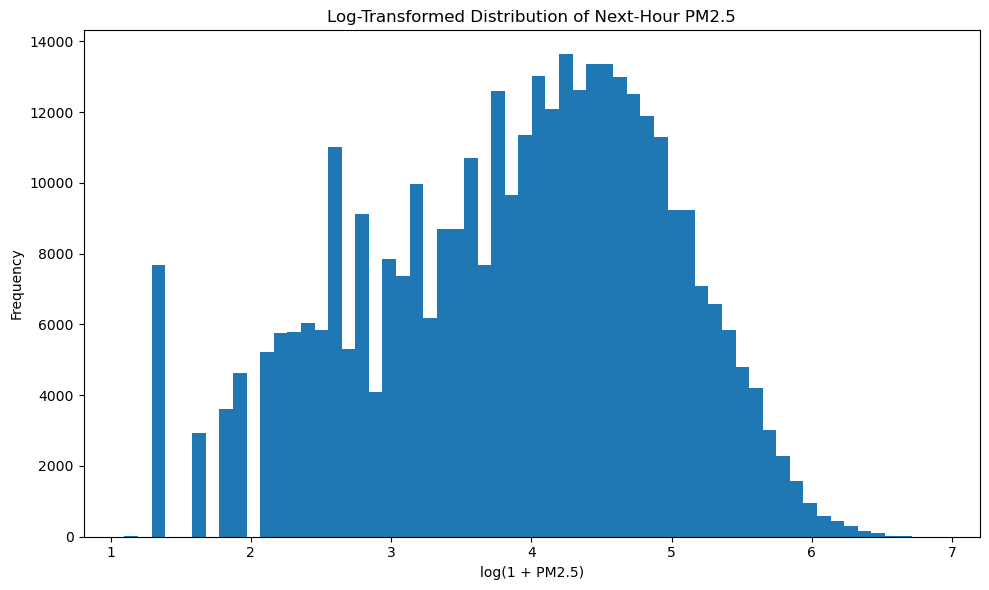

In [9]:
plt.figure(figsize=(10, 6))

plt.hist(
    np.log1p(train[target]),
    bins=60
)

plt.xlabel("log(1 + PM2.5)")
plt.ylabel("Frequency")
plt.title("Log-Transformed Distribution of Next-Hour PM2.5")

plt.tight_layout()
plt.show()

In [10]:
# SKEWNESS

print("Target mean  :", train[target].mean())
print("Target median:", train[target].median())
print("Target std   :", train[target].std())
print("Target skew  :", train[target].skew())
print("Target max   :", train[target].max())

Target mean  : 78.04397901117595
Target median: 55.0
Target std   : 77.77792994682846
Target skew  : 2.013255422324208
Target max   : 999.0


In [11]:
# EXTREME POLLUTION

thresholds = [35, 75, 150, 250, 300]

for threshold in thresholds:
    pct = (train[target] > threshold).mean() * 100
    print(
        f"PM2.5 > {threshold:3}: "
        f"{pct:.2f}% of observations"
    )

PM2.5 >  35: 62.96% of observations
PM2.5 >  75: 38.50% of observations
PM2.5 > 150: 14.29% of observations
PM2.5 > 250: 4.09% of observations
PM2.5 > 300: 2.09% of observations


current_PM2_5    0.97
PM10             0.85
CO               0.76
NO2              0.64
SO2              0.50
DEWP             0.12
PRES             0.02
RAIN            -0.03
TEMP            -0.12
O3              -0.13
WSPM            -0.28
Name: PM2_5_next_hour, dtype: float64

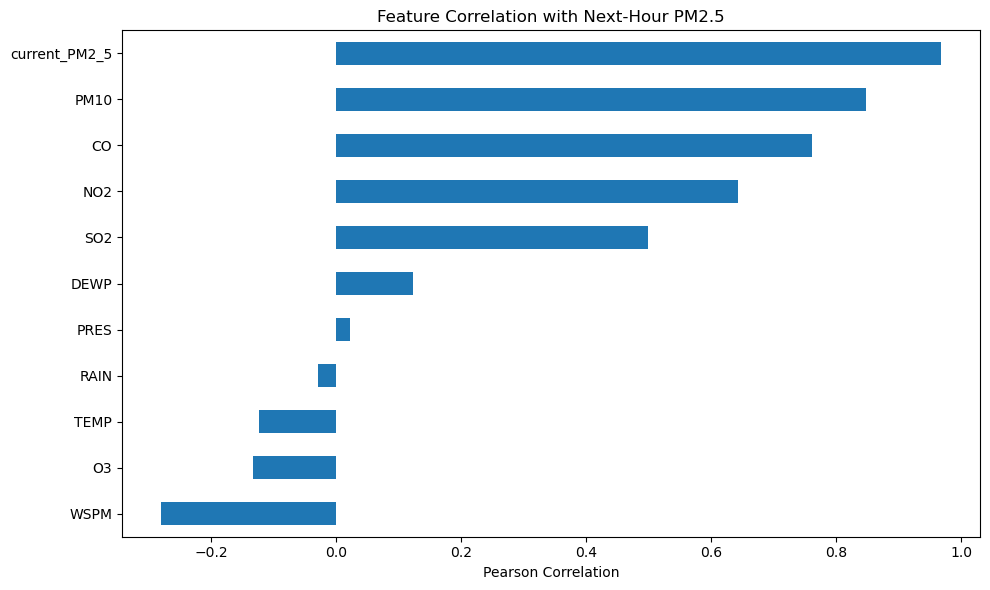

In [14]:
# CORRELATION WITH TARGET

corr = (
    train[numerical_cols]
    .corr()[target]
    .drop(target)
    .sort_values(ascending=False)
)

display(corr)

plt.figure(figsize=(10, 6))

corr.sort_values().plot(kind="barh")

plt.xlabel("Pearson Correlation")
plt.title("Feature Correlation with Next-Hour PM2.5")

plt.tight_layout()
plt.show()

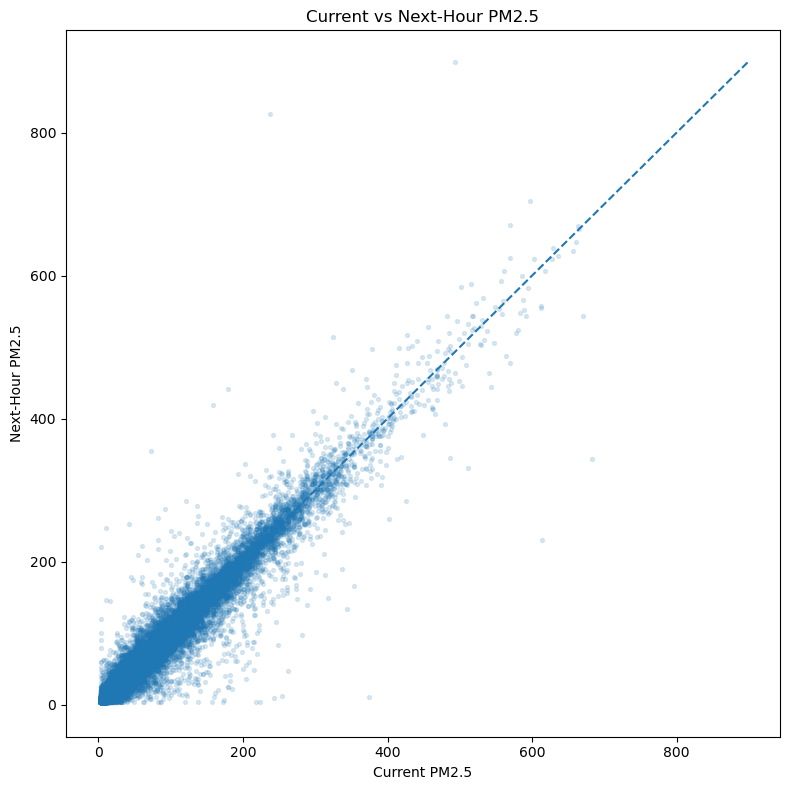

In [15]:
# CURRENT VS NEXT-HOUR PM2.5

sample = train.sample(
    min(30000, len(train)),
    random_state=42
)

plt.figure(figsize=(8, 8))

plt.scatter(
    sample["current_PM2_5"],
    sample["PM2_5_next_hour"],
    alpha=0.15,
    s=8
)

max_val = max(
    sample["current_PM2_5"].max(),
    sample["PM2_5_next_hour"].max()
)

plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--"
)

plt.xlabel("Current PM2.5")
plt.ylabel("Next-Hour PM2.5")
plt.title("Current vs Next-Hour PM2.5")

plt.tight_layout()
plt.show()

In [16]:
# PERSISTENCE BASELINE

baseline_df = train.dropna(
    subset=["current_PM2_5", "PM2_5_next_hour"]
).copy()

baseline_df["persistence_error"] = (
    baseline_df["PM2_5_next_hour"]
    - baseline_df["current_PM2_5"]
)

baseline_df["absolute_persistence_error"] = (
    baseline_df["persistence_error"].abs()
)

mae = baseline_df[
    "absolute_persistence_error"
].mean()

rmse = np.sqrt(
    np.mean(
        baseline_df["persistence_error"] ** 2
    )
)

print(f"Persistence MAE : {mae:.3f}")
print(f"Persistence RMSE: {rmse:.3f}")

Persistence MAE : 10.405
Persistence RMSE: 19.671


In [17]:
# PM2.5 CHANGE BETWEEN HOURS

baseline_df["PM2_5_change"] = (
    baseline_df["PM2_5_next_hour"]
    - baseline_df["current_PM2_5"]
)

display(
    baseline_df["PM2_5_change"].describe(
        percentiles=[
            0.01, 0.05, 0.25,
            0.5,
            0.75, 0.95, 0.99
        ]
    )
)

plt.figure(figsize=(10, 6))

plt.hist(
    baseline_df.loc[
        baseline_df["PM2_5_change"].between(-100, 100),
        "PM2_5_change"
    ],
    bins=80
)

plt.axvline(0, linestyle="--")

plt.xlabel("PM2.5(t+1) - PM2.5(t)")
plt.ylabel("Frequency")
plt.title("Hourly Change in PM2.5")

plt.tight_layout()
plt.show()

count   358,488.00
mean          0.11
std          19.67
min        -628.00
1%          -61.00
5%          -25.00
25%          -5.00
50%           0.00
75%           6.00
95%          23.00
99%          49.00
max         853.00
Name: PM2_5_change, dtype: float64